# Week 1: Telco Churn EDA
This notebook provides a first look at the Telco Customer Churn dataset.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import sys

# Add src to path so we can use our internal modules
sys.path.append(os.path.abspath("../"))

from src.ingestion.load_churn_data import load_churn_data
from src.features.preprocess import clean_churn_data
from src.config import TARGET_COL

## 1. Load Data

In [2]:
df = load_churn_data()
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df = clean_churn_data(df)

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Basic Stats

In [5]:
df.info()
print("\nMissing values per column:\n", df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

## 3. Class Distribution

In [6]:
churn_counts = df[TARGET_COL].value_counts(normalize=True)
print(churn_counts)

# Imagine you have a small dataset of 10 customers:
# 7 customers stayed (No)
# 3 customers left (Yes)

# Without normalize=True:
# df['Churn'].value_counts()
# # Result:
# # No     7
# # Yes    3
# With normalize=True:
# df['Churn'].value_counts(normalize=True)
# # Result:
# # No     0.7
# # Yes    0.3
#normalize gives you percentages

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


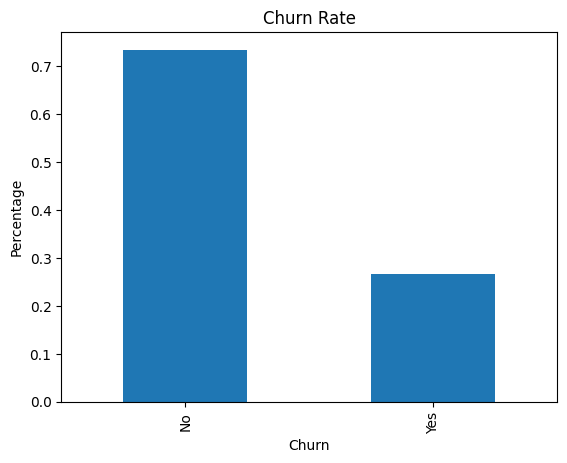

In [7]:
churn_counts.plot(kind='bar', title='Churn Rate')
plt.ylabel('Percentage')
plt.show()

## 4. Summary of Observations
- The dataset contains roughly 26% churned customers (class imbalance).
- TotalCharges had string values that needed numeric conversion.
- Most features are categorical.

## 5. Model Training & Comparison (Week 2)
Here we use the extended evaluation and feature importance functions.

In [8]:
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, roc_curve

from src.features.preprocess import build_preprocessing_pipeline, get_feature_names
from src.evaluation.evaluate import get_metrics_report, format_metrics_report
from src.config import ID_COL

%matplotlib inline

In [9]:
# Prepare Features & Target
y = df[TARGET_COL].apply(lambda x: 1 if x == 'Yes' else 0)
X = df.drop(columns=[TARGET_COL, ID_COL])

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")

Train shape: (5634, 19)
Test shape: (1409, 19)


In [10]:
def train_and_display_results(model, model_name):
    # Build Pipeline
    preprocessor = build_preprocessing_pipeline()
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    # Train
    pipeline.fit(X_train, y_train)
    
    # Predict
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]
    
    # Metrics
    metrics = get_metrics_report(y_test, y_pred, y_prob)
    print(format_metrics_report(metrics, model_name=model_name))
    
    # Plots
    fig, ax = plt.subplots(1, 3, figsize=(18, 5))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[0])
    ax[0].set_title(f'Confusion Matrix - {model_name}')
    ax[0].set_xlabel('Predicted')
    ax[0].set_ylabel('Actual')
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    ax[1].plot(fpr, tpr, label=f'AUC: {metrics["ROC-AUC"]:.4f}')
    ax[1].plot([0, 1], [0, 1], 'k--')
    ax[1].set_title(f'ROC Curve - {model_name}')
    ax[1].legend()
    
    # Feature Importance
    feat_names = get_feature_names(pipeline.named_steps['preprocessor'])
    importances = None
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
    elif hasattr(model, 'coef_'):
        importances = np.abs(model.coef_[0])
        
    if importances is not None:
        feat_imp = pd.Series(importances, index=feat_names).sort_values(ascending=False).head(15)
        feat_imp.plot(kind='barh', ax=ax[2])
        ax[2].set_title(f'Top 15 Features - {model_name}')
        
    plt.tight_layout()
    plt.show()
    
    return pipeline

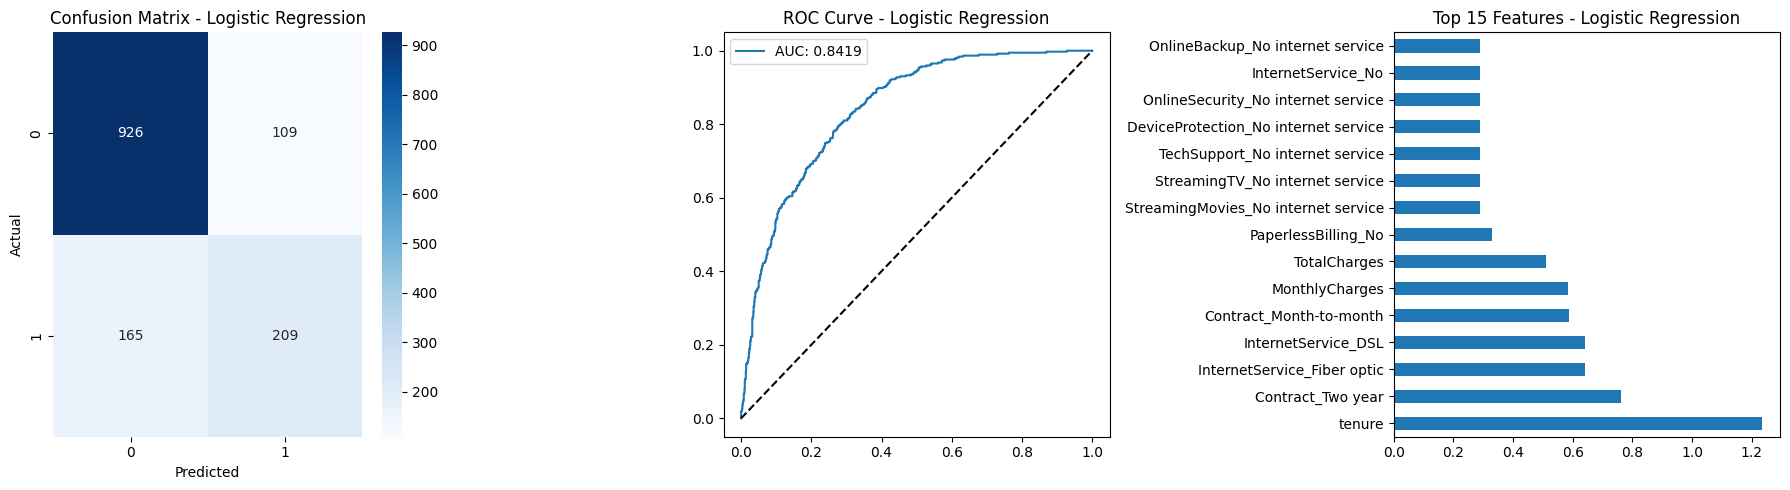

In [11]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_pipeline = train_and_display_results(lr_model, "Logistic Regression")

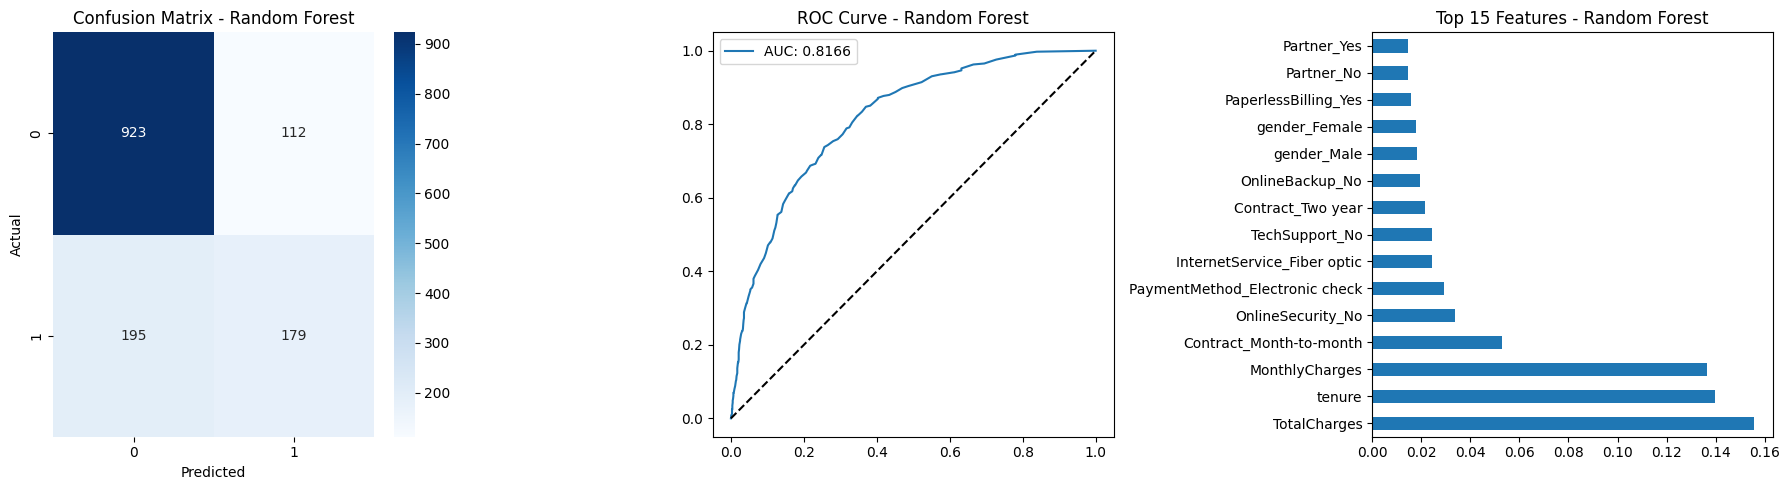

In [12]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_pipeline = train_and_display_results(rf_model, "Random Forest")

## 6. Conclusion
- Logistic Regression performs slightly better in terms of ROC-AUC for this dataset.
- Tenure and Contract type are consistently among the most important features.